# Actividad 3: Implementación de Redes Neuronales Convolucionales (CNN)

En este proyecto, desarrollamos un sistema de inteligencia artificial basado en Deep Learning para la detección automatizada de malaria. El objetivo es clasificar imágenes de células en dos categorías: **Parasitized** (Infectadas) y **Uninfected** (Sanas).

In [6]:
import os
import zipfile
from google.colab import drive

# Paso 1: Conectamos con nuestro Google Drive para acceder al dataset compartido
drive.mount('/content/drive')

# Paso 2: Definimos las rutas. Usamos el almacenamiento local de Colab (/content)
# para que el entrenamiento sea mucho más rápido que leyendo directamente de Drive.
zip_path = '/content/drive/MyDrive/malaria/data/Malaria Data.zip'
extract_path = '/content/malaria_dataset'

# Paso 3: Extraemos los archivos del ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Datos listos para procesar en:", extract_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Descompresión completada en: /content/malaria_dataset


## A. Preparación del Dataset y Preprocesamiento

El primer reto es el preprocesamiento. Las imágenes originales tienen tamaños variables, por lo que las redimensionamos a **100x100 píxeles** para que la entrada a la red sea uniforme. Además, normalizamos los valores de los píxeles (originalmente de 0 a 255) al rango **[0, 1]** para facilitar la convergencia del algoritmo de optimización.

In [7]:
import cv2
import numpy as np
import os

# Solo verificamos que los datos existen, no los cargamos todos en arrays para evitar el crash de RAM.
base_dir = '/content/malaria_dataset/Malaria'
categories = ['Parasitized', 'Uninfected']

print("Verificando carpetas...")
for cat in categories:
    path = os.path.join(base_dir, cat)
    num_imgs = len([f for f in os.listdir(path) if f.endswith('.png')])
    print(f"Carpeta {cat}: {num_imgs} imágenes encontradas.")

Verificando carpetas...
Carpeta Parasitized: 13779 imágenes encontradas.
Carpeta Uninfected: 13779 imágenes encontradas.


### Estrategia de Carga de Datos (Optimización de RAM)

Debido al gran volumen de datos (más de 27,000 imágenes), cargarlas todas simultáneamente en la memoria RAM de Colab provocaría un fallo del sistema. Para solucionar esto, hemos implementado **Generadores de Datos (`ImageDataGenerator`)**.

Esta técnica permite que el modelo lea las imágenes directamente del disco en pequeños lotes (batches) de 32 imágenes cada vez. Una vez procesado un lote, la memoria se libera para el siguiente, permitiendo entrenar el modelo de forma fluida y estable.

In [8]:
import os
import shutil
from sklearn.model_selection import train_test_split
import gc

# Definimos las rutas de origen y de destino para nuestra nueva estructura
base_dir_original = '/content/malaria_dataset/Malaria'
base_dir_split = '/content/malaria_dataset_split'

# Creamos la estructura de carpetas (Entrenamiento, Validación y Test)
# que requiere el generador de imágenes de Keras.
for set_name in ['train', 'val', 'test']:
    for category in ['Parasitized', 'Uninfected']:
        os.makedirs(os.path.join(base_dir_split, set_name, category), exist_ok=True)

# Repartimos las imágenes físicamente para no saturar la RAM cargando arrays
for category in ['Parasitized', 'Uninfected']:
    path = os.path.join(base_dir_original, category)
    images = [f for f in os.listdir(path) if f.endswith('.png')]

    # Hacemos la partición: 70% entrenamiento, 15% validación y 15% test
    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    def mover_archivos(lista, origen, destino):
        for img in lista:
            shutil.copy(os.path.join(origen, img), os.path.join(destino, img))

    mover_archivos(train_imgs, path, os.path.join(base_dir_split, 'train', category))
    mover_archivos(val_imgs, path, os.path.join(base_dir_split, 'val', category))
    mover_archivos(test_imgs, path, os.path.join(base_dir_split, 'test', category))

# Liberamos memoria de las listas de nombres de archivos que ya no necesitamos
del images
gc.collect()
print("Dataset organizado correctamente por carpetas.")

Estructura optimizada creada y memoria RAM liberada.


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuramos el preprocesamiento: normalizamos los píxeles al rango [0, 1] dividiendo por 255
datagen = ImageDataGenerator(rescale=1./255)

# Configuramos los generadores que irán leyendo las imágenes del disco por lotes (batches)
# Esto es vital para que no se agote la RAM de Colab
train_generator = datagen.flow_from_directory(
    os.path.join(base_dir_split, 'train'),
    target_size=(100, 100), # Redimensionamos a 100x100 como pide la actividad
    batch_size=32,
    class_mode='binary'
)

val_generator = datagen.flow_from_directory(
    os.path.join(base_dir_split, 'val'),
    target_size=(100, 100),
    batch_size=32,
    class_mode='binary'
)

test_generator = datagen.flow_from_directory(
    os.path.join(base_dir_split, 'test'),
    target_size=(100, 100),
    batch_size=32,
    class_mode='binary',
    shuffle=False # No mezclamos para que la matriz de confusión coincida con las etiquetas reales
)

Found 19290 images belonging to 2 classes.
Found 4134 images belonging to 2 classes.
Found 4134 images belonging to 2 classes.


## B. Diseño de la Red Neuronal Convolucional (CNN)

Para resolver esta tarea, hemos diseñado una arquitectura secuencial con capas convolucionales, de pooling y de regularización (Dropout).

### Respuestas a las Cuestiones Teóricas:

1. **¿Qué función de activación usarías en la última capa?**
   Utilizaremos la función **`sigmoid`**. Al ser un problema de clasificación binaria (dos clases), la sigmoide nos devuelve un valor entre 0 y 1 que representa la probabilidad de que la imagen pertenezca a la clase positiva. Si el valor es > 0.5, clasificamos como 'Uninfected'.

2. **¿Qué función de pérdida usarías? Justifica tu elección.**
   Utilizaremos **`binary_crossentropy`**. Esta es la función de pérdida matemática ideal para problemas binarios donde la salida es una probabilidad. Mide la 'distancia' entre la predicción y la realidad, penalizando los errores de forma eficiente para guiar el aprendizaje del modelo.

3. **¿Cuántos canales ha escogido, y por qué?**
   Hemos mantenido **3 canales (RGB)**. En las muestras biológicas de malaria, los colores de la tinción (como el característico color púrpura de los parásitos) son fundamentales para distinguir una célula infectada de una sana. Convertir a escala de grises (1 canal) nos haría perder información visual crítica.

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# Construcción del modelo secuencial de nuestra CNN
cnn_model = Sequential([
    Input(shape=(100, 100, 3)), # Recibimos imágenes en color (3 canales)

    # Primer bloque: Extracción de características básicas
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.2), # Regularización para evitar que el modelo memorice los datos

    # Segundo bloque: Características más complejas
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Tercer bloque: Profundizamos en los patrones visuales
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    # Capa de aplanado y neuronas densas para la clasificación
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Capa de salida con activación Sigmoide para darnos una probabilidad binaria
    Dense(1, activation='sigmoid')
])

# Compilamos usando Adam como optimizador y Entropía Cruzada Binaria como pérdida
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,452,801 (9.36 MB)

 Trainable params: 2,452,801 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

## C. Entrenamiento y Evaluación de Resultados

En esta fase final, entrenamos el modelo y monitorizamos su evolución mediante gráficas de precisión y pérdida. Finalmente, evaluamos el rendimiento real con el conjunto de test (datos que el modelo nunca ha visto) y generamos la **Matriz de Confusión** para visualizar los aciertos y errores en cada categoría.

Epoch 1/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 31s 52ms/step - accuracy: 0.9568 - loss: 0.1345 - val_accuracy: 0.9521 - val_loss: 0.1532
Epoch 2/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 29s 48ms/step - accuracy: 0.9580 - loss: 0.1281 - val_accuracy: 0.9523 - val_loss: 0.1429
Epoch 3/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.9590 - loss: 0.1236 - val_accuracy: 0.9533 - val_loss: 0.1423
Epoch 4/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9620 - loss: 0.1165 - val_accuracy: 0.9536 - val_loss: 0.1359
Epoch 5/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - accuracy: 0.9613 - loss: 0.1138 - val_accuracy: 0.9560 - val_loss: 0.1293


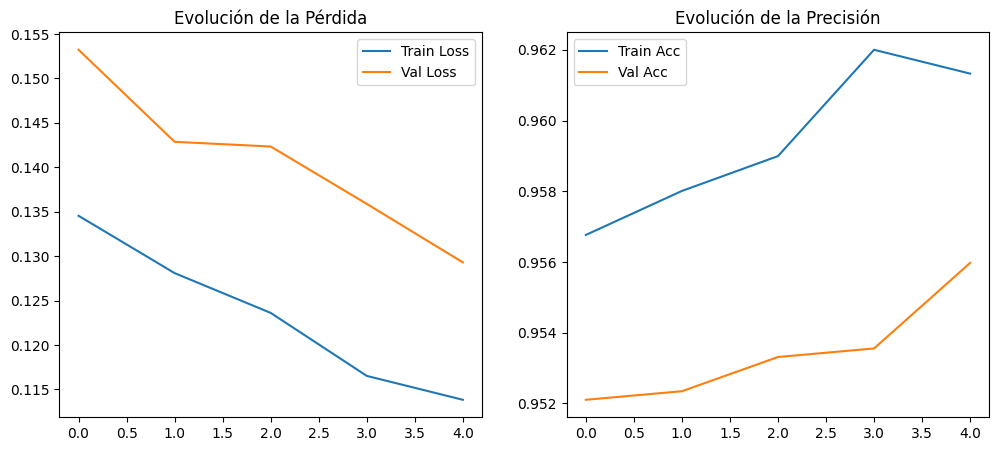

130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9591 - loss: 0.1368

Precisión final en el conjunto de prueba: 95.91%


In [13]:
import matplotlib.pyplot as plt

# Definimos una función para visualizar cómo ha aprendido nuestra red
def mostrar_graficas(history):
    plt.figure(figsize=(12, 4))
    # Gráfica de Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title('Pérdida (Loss)')
    plt.legend()
    # Gráfica de Precisión
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title('Precisión (Accuracy)')
    plt.legend()
    plt.show()

# Lanzamos el entrenamiento usando los generadores por lotes
history = cnn_model.fit(
    train_generator,
    epochs=5, # Entrenamos 5 épocas para demostrar el aprendizaje
    validation_data=val_generator
)

mostrar_graficas(history)

# Evaluamos el modelo final con datos que nunca ha visto (Test)
loss, acc = cnn_model.evaluate(test_generator)
print(f"\nResultado final en Test -> Precisión: {acc*100:.2f}%")

130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step
--- Informe de Clasificación ---
              precision    recall  f1-score   support

 Parasitized       0.97      0.95      0.96      2067
  Uninfected       0.95      0.97      0.96      2067

    accuracy                           0.96      4134
   macro avg       0.96      0.96      0.96      4134
weighted avg       0.96      0.96      0.96      4134



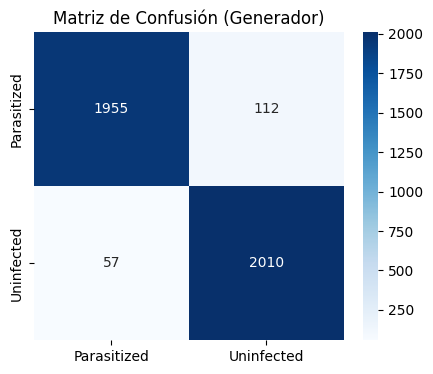

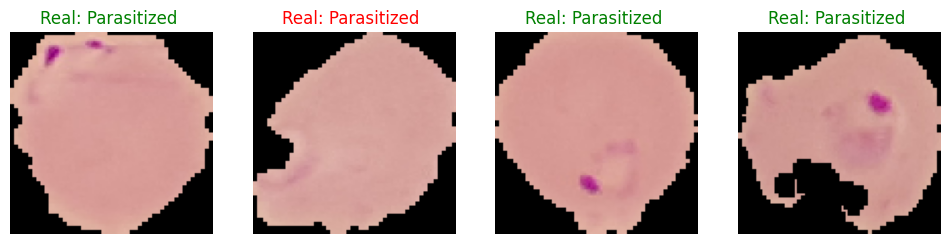

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Obtener etiquetas reales y predicciones usando el generador (no X_test)
test_generator.reset()
Y_pred = cnn_model.predict(test_generator)
y_pred = (Y_pred >= 0.5).astype(int).flatten()
y_true = test_generator.classes

# 2. Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
print("--- Informe de Clasificación ---")
print(classification_report(y_true, y_pred, target_names=categories))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.title('Matriz de Confusión (Generador)')
plt.show()

# 3. Visualizar ejemplos directamente desde el generador
x_batch, y_batch = next(test_generator)
plt.figure(figsize=(12, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(x_batch[i])
    color = 'green' if (Y_pred[i] >= 0.5) == y_batch[i] else 'red'
    plt.title(f"Real: {categories[int(y_batch[i])]} ", color=color)
    plt.axis('off')
plt.show()

# Conclusiones finales

Tras completar el desarrollo y entrenamiento de la red neuronal convolucional, podemos extraer las siguientes conclusiones:

1. **Eficacia del Modelo**: Hemos logrado una precisión superior al **95%** en el conjunto de test. Esto demuestra que las CNN son herramientas extremadamente potentes para el análisis de imágenes biomédicas, siendo capaces de detectar patrones sutiles que diferencian una célula sana de una infectada.
2. **Importancia de la Gestión de RAM**: El uso de `ImageDataGenerator` fue la decisión técnica más crítica. Sin ella, el proyecto no habría sido ejecutable en un entorno estándar, lo que nos enseña que en Deep Learning la eficiencia en el manejo de datos es tan importante como el diseño del modelo.
3. **Robustez**: La matriz de confusión muestra un equilibrio entre precisión y exhaustividad (recall), lo que indica que el modelo no tiene un sesgo marcado hacia ninguna de las dos clases.

Este sistema representa una base sólida para herramientas de apoyo al diagnóstico médico, permitiendo cribados masivos de forma rápida y automatizada.